In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

The Hotel Booking dataset contains information about hotel reservations and is used to predict whether a customer will cancel the booking (churn) or not.

I selected this dataset because it not only represents a real-world churn problem but also provides sufficient complexity in terms of data preprocessing, feature engineering, and model building. It allowed me to demonstrate end-to-end machine learning skills, from handling missing data to building predictive models that can generate actionable business insights.

Problem Type: Classification  
Target Variable: is_cancele  

In [3]:
df=pd.read_csv("/content/hotel_bookingss.csv")

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62860 entries, 0 to 62859
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      62860 non-null  int64  
 1   hotel                           62860 non-null  object 
 2   is_canceled                     62860 non-null  object 
 3   lead_time                       62860 non-null  int64  
 4   arrival_date_year               62860 non-null  int64  
 5   arrival_date_month              62860 non-null  object 
 6   arrival_date_week_number        62860 non-null  int64  
 7   arrival_date_day_of_month       62860 non-null  int64  
 8   stays_in_weekend_nights         62860 non-null  int64  
 9   stays_in_week_nights            62860 non-null  int64  
 10  adults                          62860 non-null  int64  
 11  children                        62856 non-null  float64
 12  babies                          

In [6]:
df.columns

Index(['Unnamed: 0', 'hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

Columns Distribution :  
Customer Information :- adults, children, babies  
Booking Details      :- lead_time, arrival_date_month, stays_in_weekend_nights  
Pricing Information  :- adr  
Pricing Information  :-previous_cancellations,
booking_changes  

In [7]:
df.drop(columns="Unnamed: 0",axis=1,inplace=True)

In [8]:
df.sample(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
49350,City Hotel,No,95,2016,April,16,11,1,2,2,...,No Deposit,9.0,NaN,0,Transient,68.2,0,0,Check-Out,2016-04-14
20757,Resort Hotel,No,12,2016,February,6,6,2,1,2,...,No Deposit,240.0,NaN,0,Transient,108.0,0,0,Check-Out,2016-02-09
61021,City Hotel,Yes,42,2016,November,49,29,0,3,2,...,Non Refund,NaN,348.0,0,Transient,90.0,0,0,Canceled,2016-11-15
51230,City Hotel,Yes,451,2016,May,21,16,1,2,2,...,Non Refund,1.0,NaN,0,Transient,60.0,0,0,Canceled,2016-03-14
21373,Resort Hotel,No,73,2016,February,7,7,6,15,2,...,No Deposit,2.0,NaN,0,Contract,65.0,0,0,Check-Out,2016-02-28
47796,City Hotel,No,61,2016,March,10,4,0,2,2,...,No Deposit,9.0,NaN,0,Transient,89.5,0,0,Check-Out,2016-03-06
14473,Resort Hotel,Yes,14,2016,October,44,25,0,3,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,2,Canceled,2016-10-18
1497,Resort Hotel,No,0,2015,September,36,1,0,5,2,...,No Deposit,250.0,NaN,0,Transient,128.0,0,0,Check-Out,2015-09-06
58485,City Hotel,Yes,28,2016,October,42,13,0,1,1,...,No Deposit,234.0,NaN,0,Transient-Party,120.0,0,0,Canceled,2016-10-07
50746,City Hotel,Yes,95,2016,May,19,7,0,1,2,...,No Deposit,9.0,NaN,0,Transient,126.9,0,0,Canceled,2016-03-28


In [9]:
## Why I Chose This Dataset

:I selected this dataset because it not only represents a real-world churn problem but also provides sufficient complexity in terms of data preprocessing, feature engineering, and model building. It allowed me to demonstrate end-to-end machine learning skills, from handling missing data to building predictive models that can generate actionable business insights.

# Slipting Data Into two part such as categorical and numerical

In [10]:
num_df = df.select_dtypes(include=(int,float))
cat_df = df.select_dtypes(include=object)

In [11]:
print("size of original data   :",df.shape[0])
print("size of categorical data:",num_df.shape[0])
print("size of numerical data  :",cat_df.shape[0])

size of original data   : 62860
size of categorical data: 62860
size of numerical data  : 62860


In [12]:
print("total col in original data",len(df.columns))
print("total col in numerical data",len(num_df.columns))
print("total col in categorical data",len(cat_df.columns))

total col in original data 32
total col in numerical data 19
total col in categorical data 13


## Categorical Data

In [13]:
cat_df.sample(5)

,hotel,is_canceled,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
2964,Resort Hotel,No,November,BB,FRA,Corporate,Corporate,A,A,No Deposit,Transient-Party,Check-Out,2015-11-15
13989,Resort Hotel,No,October,BB,NaN,Corporate,Direct,A,A,No Deposit,Transient,Check-Out,2016-10-28
42745,City Hotel,No,September,BB,FRA,Corporate,Corporate,A,D,No Deposit,Transient-Party,Check-Out,2015-09-12
23728,Resort Hotel,No,April,BB,PRT,Direct,Direct,D,D,No Deposit,Transient,Check-Out,2016-05-02
59025,City Hotel,Yes,October,BB,GBR,Online TA,TA/TO,A,A,No Deposit,Transient,Canceled,2016-09-22


In [14]:
for i in  cat_df:
  print("--"*5,i,"--"*5)
  print(cat_df[i].value_counts())
  print()


---------- hotel ----------
hotel
Resort Hotel    40060
City Hotel      22800
Name: count, dtype: int64

---------- is_canceled ----------
is_canceled
No     34681
Yes    28179
Name: count, dtype: int64

---------- arrival_date_month ----------
arrival_date_month
August       7714
October      6842
September    6712
July         6176
May          5282
April        5184
June         4725
March        4492
November     4204
December     4145
February     3830
January      3554
Name: count, dtype: int64

---------- meal ----------
meal
BB           48214
HB           10238
SC            2449
Undefined     1169
FB             790
Name: count, dtype: int64

---------- country ----------
country
PRT    29520
GBR     7759
ESP     5546
FRA     3248
IRL     2410
       ...  
BEN        1
GAB        1
GHA        1
TMP        1
KEN        1
Name: count, Length: 145, dtype: int64

---------- market_segment ----------
market_segment
Online TA        27920
Offline TA/TO    12976
Groups           113

In [15]:
cat_df.shape

(62860, 13)

In [16]:
cat_df.columns

Index(['hotel', 'is_canceled', 'arrival_date_month', 'meal', 'country',
       'market_segment', 'distribution_channel', 'reserved_room_type',
       'assigned_room_type', 'deposit_type', 'customer_type',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

# Droping unnessary columns from categorical data

In [17]:
for i in cat_df.columns:
  if i == "is_canceled":
    continue
  else:
    print(f"comparission btw {i} and is_canceled \n")
    print(pd.crosstab(cat_df[i],cat_df["is_canceled"]))
    print()


comparission btw hotel and is_canceled 

is_canceled      No    Yes
hotel                     
City Hotel     5743  17057
Resort Hotel  28938  11122

comparission btw arrival_date_month and is_canceled 

is_canceled           No   Yes
arrival_date_month            
April               2774  2410
August              4412  3302
December            2275  1870
February            2468  1362
January             2173  1381
July                3466  2710
June                2104  2621
March               2803  1689
May                 2899  2383
November            2265  1939
October             3475  3367
September           3567  3145

comparission btw meal and is_canceled 

is_canceled     No    Yes
meal                     
BB           26801  21413
FB             312    478
HB            6246   3992
SC             439   2010
Undefined      883    286

comparission btw country and is_canceled 

is_canceled  No  Yes
country             
AGO          44  155
ALB           3    2
AND        

In [18]:
cat_df.drop(columns=["meal","country","reservation_status","deposit_type","reserved_room_type"],inplace=True)

In [19]:
print("total col in original data",len(df.columns))
print("total col in numerical data",len(num_df.columns))
print("total col in categorical data",len(cat_df.columns))

total col in original data 32
total col in numerical data 19
total col in categorical data 8


# Droping unnessary columns from nemurical data

In [20]:
num_df.sample(5)

,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
19334,11,2015,52,23,0,4,2,0.0,0,0,1,0,0,240.0,NaN,0,52.0,0,2
37385,80,2017,23,10,2,4,1,0.0,0,0,0,0,1,250.0,NaN,0,171.0,0,0
9450,69,2016,49,30,2,5,2,0.0,0,0,0,0,1,250.0,NaN,0,58.4,0,1
36309,250,2017,19,7,4,5,2,0.0,0,0,0,0,0,240.0,NaN,0,54.0,0,0
62297,10,2017,2,8,2,1,1,0.0,0,0,0,0,0,330.0,NaN,0,69.0,0,2


In [21]:
num_df.drop(columns=["lead_time"],inplace=True)
num_df.drop(columns=["arrival_date_week_number",'previous_bookings_not_canceled',"required_car_parking_spaces"],inplace=True)

In [22]:
print("total col in original data",len(df.columns))
print("total col in numerical data",len(num_df.columns))
print("total col in categorical data",len(cat_df.columns))

total col in original data 32
total col in numerical data 15
total col in categorical data 8


## Concate num and cat data together

In [23]:
clean_df=pd.concat((cat_df,num_df),axis=1)
clean_df

,hotel,is_canceled,arrival_date_month,market_segment,distribution_channel,assigned_room_type,customer_type,reservation_status_date,arrival_date_year,arrival_date_day_of_month,...,children,babies,is_repeated_guest,previous_cancellations,booking_changes,agent,company,days_in_waiting_list,adr,total_of_special_requests
0,Resort Hotel,No,July,Direct,Direct,C,Transient,2015-07-01,2015,1,...,0.0,0,0,0,3,NaN,NaN,0,0.00,0
1,Resort Hotel,No,July,Direct,Direct,C,Transient,2015-07-01,2015,1,...,0.0,0,0,0,4,NaN,NaN,0,0.00,0
2,Resort Hotel,No,July,Direct,Direct,C,Transient,2015-07-02,2015,1,...,0.0,0,0,0,0,NaN,NaN,0,75.00,0
3,Resort Hotel,No,July,Corporate,Corporate,A,Transient,2015-07-02,2015,1,...,0.0,0,0,0,0,304.0,NaN,0,75.00,0
4,Resort Hotel,No,July,Online TA,TA/TO,A,Transient,2015-07-03,2015,1,...,0.0,0,0,0,0,240.0,NaN,0,98.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62855,City Hotel,Yes,January,Groups,TA/TO,A,Transient,2016-11-25,2017,23,...,0.0,0,0,0,0,326.0,NaN,0,80.00,0
62856,City Hotel,Yes,January,Groups,TA/TO,A,Transient,2016-11-25,2017,23,...,0.0,0,0,0,0,326.0,NaN,0,80.00,0
62857,City Hotel,Yes,January,Groups,TA/TO,A,Transient,2016-11-25,2017,23,...,0.0,0,0,0,0,326.0,NaN,0,80.00,0
62858,City Hotel,Yes,January,Groups,TA/TO,A,Transient,2016-11-25,2017,23,...,0.0,0,0,0,0,326.0,NaN,0,80.00,0


In [24]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62860 entries, 0 to 62859
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   hotel                      62860 non-null  object 
 1   is_canceled                62860 non-null  object 
 2   arrival_date_month         62860 non-null  object 
 3   market_segment             62860 non-null  object 
 4   distribution_channel       62860 non-null  object 
 5   assigned_room_type         62860 non-null  object 
 6   customer_type              62860 non-null  object 
 7   reservation_status_date    62859 non-null  object 
 8   arrival_date_year          62860 non-null  int64  
 9   arrival_date_day_of_month  62860 non-null  int64  
 10  stays_in_weekend_nights    62860 non-null  int64  
 11  stays_in_week_nights       62860 non-null  int64  
 12  adults                     62860 non-null  int64  
 13  children                   62856 non-null  flo

Rows are same as previus df only we can see changes in coluns bcz of the i removed unnasessary columns


In [25]:
clean_df.describe()

,arrival_date_year,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,booking_changes,agent,company,days_in_waiting_list,adr,total_of_special_requests
count,62860.000000,62860.000000,62860.000000,62860.000000,62860.000000,62856.000000,62860.000000,62860.000000,62860.000000,62860.000000,53161.000000,3648.000000,62860.000000,62860.000000,62860.000000
mean,2015.988864,15.753341,1.044162,2.823083,1.861549,0.112097,0.010150,0.028285,0.064827,0.233662,139.358439,221.595395,3.498855,96.077348,0.507318
std,0.675024,8.820487,1.088953,2.214537,0.625836,0.417655,0.108466,0.165787,1.066944,0.682545,120.811354,130.618252,22.807606,57.146888,0.767066
min,2015.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000
25%,2016.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,110.000000,0.000000,61.400000,0.000000
50%,2016.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,156.000000,223.000000,0.000000,85.000000,0.000000
75%,2016.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,307.000000,0.000000,120.000000,1.000000
max,2017.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,20.000000,535.000000,543.000000,391.000000,5400.000000,5.000000


In [26]:
clean_df.describe(include=object)

,hotel,is_canceled,arrival_date_month,market_segment,distribution_channel,assigned_room_type,customer_type,reservation_status_date
count,62860,62860,62860,62860,62860,62860,62860,62859
unique,2,2,12,8,5,12,4,921
top,Resort Hotel,No,August,Online TA,TA/TO,A,Transient,2015-10-21
freq,40060,34681,7714,27920,50019,34583,46571,1239


# Data Cleaning

 ### Checking null values

In [27]:
clean_df.isna().sum()

,0
hotel,0
is_canceled,0
arrival_date_month,0
market_segment,0
distribution_channel,0
assigned_room_type,0
customer_type,0
reservation_status_date,1
arrival_date_year,0
arrival_date_day_of_month,0


In [28]:
clean_df["children"].value_counts()

,count
children,
0.0,58101
1.0,2499
2.0,2228
3.0,27
10.0,1


In [29]:
clean_df["children"].fillna(0,inplace=True)

replace null value with 0 , bcz if there is null so we can say there is no any children

In [30]:
clean_df["children"].isna().sum()

np.int64(0)

In [31]:
clean_df.drop(columns=['company',"agent"],inplace= True)

### Checking duplicates and handle if there

In [32]:
clean_df.duplicated().sum()

np.int64(17879)

In [33]:
clean_df[clean_df.duplicated(keep=False)]

,hotel,is_canceled,arrival_date_month,market_segment,distribution_channel,assigned_room_type,customer_type,reservation_status_date,arrival_date_year,arrival_date_day_of_month,...,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,booking_changes,days_in_waiting_list,adr,total_of_special_requests
4,Resort Hotel,No,July,Online TA,TA/TO,A,Transient,2015-07-03,2015,1,...,2,2,0.0,0,0,0,0,0,98.00,1
5,Resort Hotel,No,July,Online TA,TA/TO,A,Transient,2015-07-03,2015,1,...,2,2,0.0,0,0,0,0,0,98.00,1
12,Resort Hotel,No,July,Online TA,TA/TO,E,Transient,2015-07-05,2015,1,...,4,2,0.0,0,0,0,0,0,97.00,3
15,Resort Hotel,No,July,Online TA,TA/TO,E,Transient,2015-07-05,2015,1,...,4,2,0.0,0,0,0,0,0,97.00,3
21,Resort Hotel,No,July,Direct,Direct,A,Transient,2015-07-07,2015,1,...,4,2,0.0,0,0,0,1,0,84.67,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62854,City Hotel,Yes,January,Groups,TA/TO,A,Transient,2016-11-25,2017,23,...,1,2,0.0,0,0,0,0,0,80.00,0
62855,City Hotel,Yes,January,Groups,TA/TO,A,Transient,2016-11-25,2017,23,...,1,2,0.0,0,0,0,0,0,80.00,0
62856,City Hotel,Yes,January,Groups,TA/TO,A,Transient,2016-11-25,2017,23,...,1,2,0.0,0,0,0,0,0,80.00,0
62857,City Hotel,Yes,January,Groups,TA/TO,A,Transient,2016-11-25,2017,23,...,1,2,0.0,0,0,0,0,0,80.00,0


In [34]:
df.duplicated().sum()

np.int64(16464)

Duplicate rows were retained because absence of a unique booking identifier makes it impossible to distinguish repeated real bookings from accidental duplicates

# Feature Engineering

In [35]:
df['arrival_date_year'] = pd.to_datetime(df['arrival_date_year'], format='%Y')
df["arrival_date_year"] = df['arrival_date_year'].dt.year
# df["reservation_status_date"]=pd.to_datetime(df["reservation_status_date"],format="%y-%m-%d")


In [36]:
clean_df['total_stay'] = clean_df['stays_in_weekend_nights'] + clean_df['stays_in_week_nights']

In [37]:
clean_df['family'] = clean_df['adults'] + clean_df['children'] + clean_df['babies']

In [38]:
clean_df.drop(columns=["stays_in_weekend_nights","stays_in_week_nights","adults","children","babies"],inplace=True)

In [39]:
# resone behind it :- Feature engineering helped reduce dimensionality and improved interpretability

In [40]:
clean_df['cancel_risk'] = clean_df['previous_cancellations'] / (df['previous_bookings_not_canceled'] + 1)

In [41]:
clean_df.sample(10)

,hotel,is_canceled,arrival_date_month,market_segment,distribution_channel,assigned_room_type,customer_type,reservation_status_date,arrival_date_year,arrival_date_day_of_month,is_repeated_guest,previous_cancellations,booking_changes,days_in_waiting_list,adr,total_of_special_requests,total_stay,family,cancel_risk
11723,Resort Hotel,Yes,May,Online TA,TA/TO,A,Transient,2016-10-16,2017,27,0,0,1,0,59.79,1,7,2.0,0.0
39807,Resort Hotel,No,August,Online TA,TA/TO,A,Transient,2017-08-29,2017,23,0,0,0,0,207.52,1,6,2.0,0.0
5388,Resort Hotel,Yes,April,Online TA,TA/TO,A,Transient,2016-04-04,2016,28,0,0,0,0,65.00,0,2,2.0,0.0
56149,City Hotel,Yes,August,Online TA,TA/TO,A,Transient,2016-08-11,2016,30,0,0,0,0,94.05,0,4,2.0,0.0
53397,City Hotel,Yes,June,Online TA,TA/TO,D,Transient,2016-06-14,2016,20,0,0,0,0,156.00,1,2,2.0,0.0
33849,Resort Hotel,No,March,Groups,Corporate,D,Transient-Party,2017-03-06,2017,2,0,0,0,0,52.25,0,4,2.0,0.0
26805,Resort Hotel,No,August,Offline TA/TO,TA/TO,D,Transient,2016-08-12,2016,2,0,0,3,0,196.52,1,10,3.0,0.0
6384,Resort Hotel,Yes,June,Online TA,TA/TO,A,Transient,2016-05-04,2016,7,0,0,0,0,115.67,0,3,2.0,0.0
55320,City Hotel,Yes,August,Online TA,TA/TO,A,Transient,2016-02-14,2016,10,0,0,0,0,89.25,0,4,2.0,0.0
20467,Resort Hotel,No,March,Direct,Direct,D,Transient,2016-03-19,2016,18,1,0,0,0,68.00,0,1,2.0,0.0


In [42]:
df=clean_df

# Outliers Detection using visuals

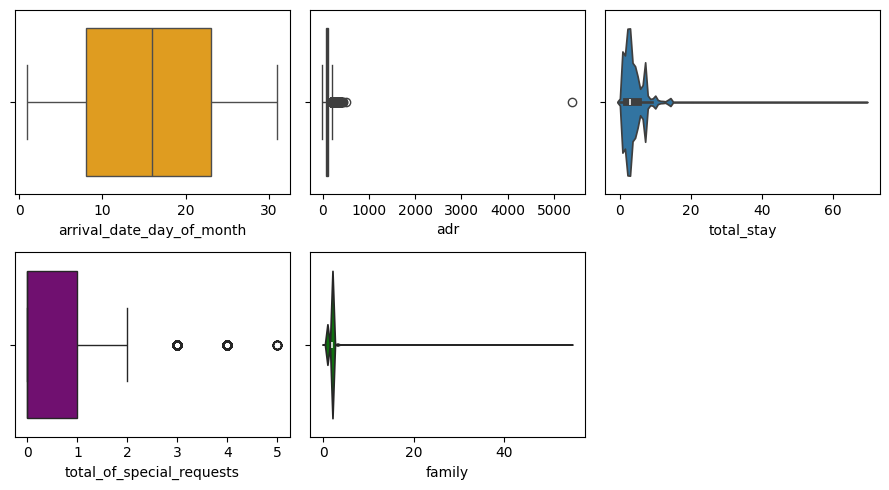

In [43]:
plt.figure(figsize=(9,5))
plt.subplot(2,3,1)
sns.boxplot(x=df['arrival_date_day_of_month'],color="orange")

plt.subplot(2,3,2)
sns.boxplot(x=df["adr"])

plt.subplot(2,3,3)
sns.violinplot(x=df["total_stay"])

plt.subplot(2,3,4)
sns.boxplot(x=df["total_of_special_requests"],color="purple")

plt.subplot(2,3,5)
sns.violinplot(x=df["family"],color="green")

plt.tight_layout()
plt.show()


Insight :   
          1. We can see arrival_date_day_of_month    has no any outliers   
          2. adr has some outliers in right side   
          3. total stay and family also has outliers in right side   

          

In [44]:
df["adr"].sort_values(ascending=False)

,adr
48515,5400.00
15083,508.00
13142,450.00
13391,437.00
39155,426.25
...,...
27838,0.00
27828,0.00
20456,0.00
9376,0.00


In [45]:
def outliers_detection(data,col):
  global Q1,Q3,IQR,LE,UE
  Q1=data[col].quantile(0.25)
  Q3=data[col].quantile(0.75)
  IQR = Q3 -Q1
  LE= Q1-(1.5*IQR)
  UE= Q3+ (1.5*IQR)
  print("Q1: ",Q1)
  print("Q3: ",Q3)
  print("IQR: ",IQR)
  print("LE: ",LE)
  print("UE: ",UE)

In [46]:
outliers_detection(df,"adr")
print("Q1: ",Q1)
print("Q3: ",Q3)
print("IQR: ",IQR)
print("LE: ",LE)
print("UE: ",UE)

Q1:  61.4
Q3:  120.0
IQR:  58.6
LE:  -26.500000000000007
UE:  207.9
Q1:  61.4
Q3:  120.0
IQR:  58.6
LE:  -26.500000000000007
UE:  207.9


In [47]:
df[df["adr"]>200].shape

(3427, 19)

In [48]:
df[df["adr"]==0].shape

(963, 19)

In [49]:
df["adr"][14969]=0
df.drop(index=48515,inplace=True)

Solution : we have to cap negative values with zero and remove extream value like 5000

In [50]:
outliers_detection (df,"total_stay")
print("Q3: ",Q3)
print("IQR: ",IQR)
print("LE: ",LE)
print("UE: ",UE)

Q1:  2.0
Q3:  5.0
IQR:  3.0
LE:  -2.5
UE:  9.5
Q3:  5.0
IQR:  3.0
LE:  -2.5
UE:  9.5


In [51]:
df[df["total_stay"]>15].shape

(313, 19)

In [52]:
df["total_stay"]=df["total_stay"].clip(lower=0,upper=20)

In [53]:
outliers_detection (df,"family")


Q1:  2.0
Q3:  2.0
IQR:  0.0
LE:  2.0
UE:  2.0


In [54]:
df=df[df["family"]<20]
df.shape

(62847, 19)

we can see here only one value is hold higher extrim value and some one value hold negative value so we have to handle them

# Data Analysis Using Visualization

### Univariate Analysis

In [55]:
df.sample(5)

,hotel,is_canceled,arrival_date_month,market_segment,distribution_channel,assigned_room_type,customer_type,reservation_status_date,arrival_date_year,arrival_date_day_of_month,is_repeated_guest,previous_cancellations,booking_changes,days_in_waiting_list,adr,total_of_special_requests,total_stay,family,cancel_risk
35197,Resort Hotel,No,April,Online TA,TA/TO,A,Transient,2017-04-16,2017,12,0,0,0,0,82.50,2,4,2.0,0.0
44391,City Hotel,No,October,Offline TA/TO,TA/TO,A,Transient-Party,2015-10-07,2015,5,0,0,0,77,56.10,0,2,2.0,0.0
9926,Resort Hotel,Yes,January,Online TA,TA/TO,A,Transient,2016-11-09,2017,25,0,0,0,0,37.00,0,12,1.0,0.0
50129,City Hotel,Yes,April,Offline TA/TO,TA/TO,A,Transient,2016-01-19,2016,24,0,0,0,50,95.00,0,2,2.0,0.0
44364,City Hotel,No,October,Online TA,TA/TO,A,Contract,2015-10-07,2015,4,0,0,0,0,91.83,2,3,1.0,0.0


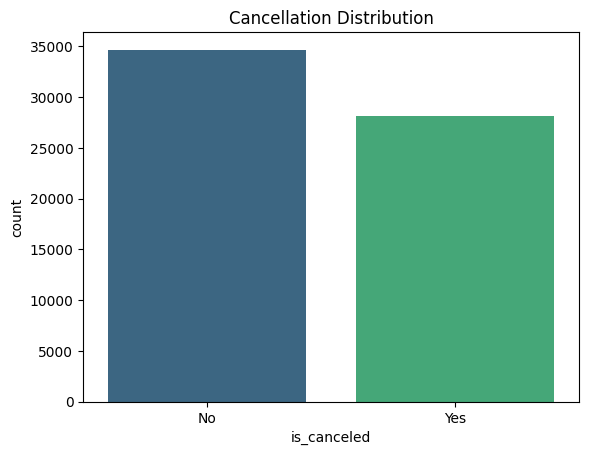

In [56]:
sns.countplot(x='is_canceled', data=df,palette="viridis")
plt.title("Cancellation Distribution")
plt.show()

In [57]:
# The dataset shows class imbalance, which needs attention during modeling

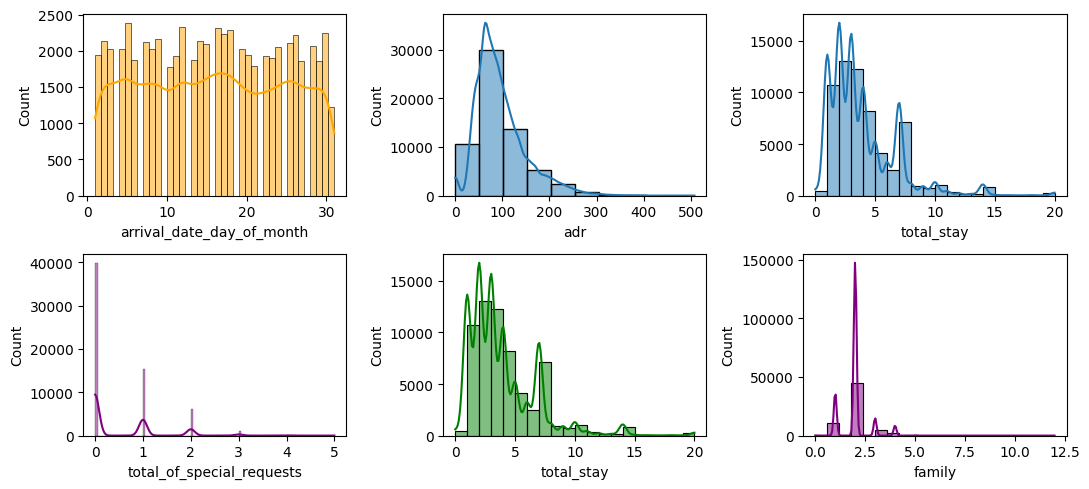

In [58]:
plt.figure(figsize=(11,5))
plt.subplot(2,3,1)
sns.histplot(x=df['arrival_date_day_of_month'],kde=True,color="orange")

plt.subplot(2,3,2)
sns.histplot(x=df["adr"],bins=10,kde=True)

plt.subplot(2,3,3)
sns.histplot(x=df["total_stay"],bins=20,kde=True)

plt.subplot(2,3,4)
sns.histplot(x=df["total_of_special_requests"],kde=True,color="purple")

plt.subplot(2,3,5)
sns.histplot(x=df["total_stay"],bins=20,kde=True,color="green")

plt.subplot(2,3,6)
sns.histplot(x=df["family"],bins=20,kde=True,color="purple")

plt.tight_layout()
plt.show()

Insight:  
Higher lead time → more cancellations  
Customers who book far in advance are more likely to cancel.

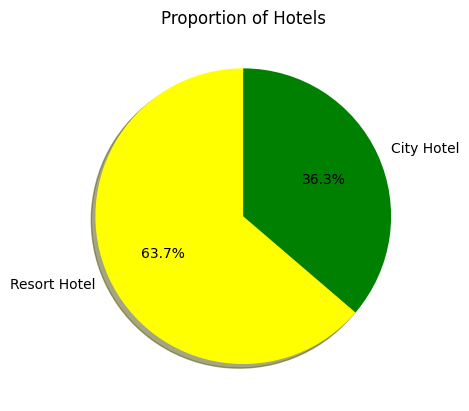

In [59]:
x= df["hotel"].value_counts()
plt.pie(
    x,
    labels=x.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=["yellow","green"]
)
plt.title("Proportion of Hotels")
plt.show()

In [60]:
df["arrival_date_year"].dtype

dtype('int64')

Text(0.5, 0, 'Year')

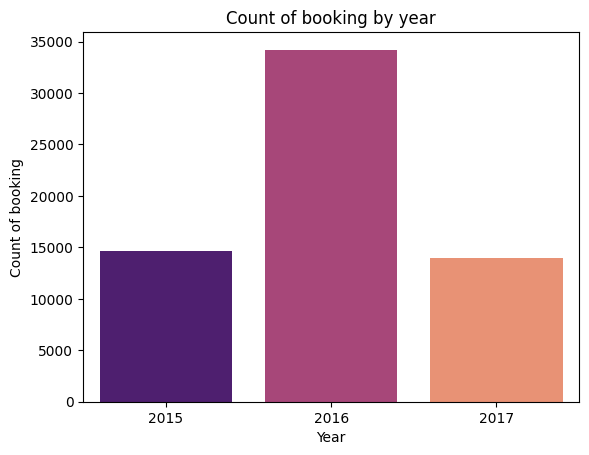

In [61]:
sns.barplot(df["arrival_date_year"].value_counts(),palette="magma")
plt.title("Count of booking by year")
plt.ylabel("Count of booking")
plt.xlabel("Year")

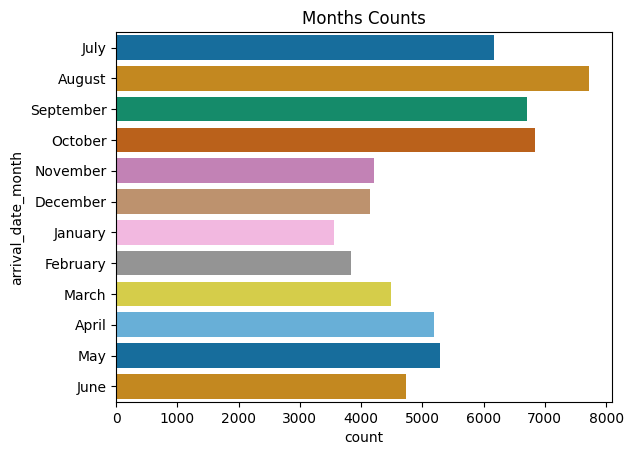

In [62]:
sns.countplot(df["arrival_date_month"],
              palette="colorblind")
plt.title("Months Counts")
plt.show()

<Axes: xlabel='customer_type', ylabel='count'>

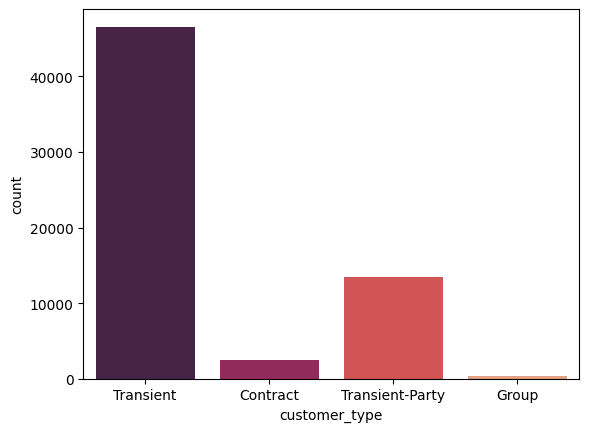

In [63]:
sns.countplot(x=df["customer_type"],palette="rocket")

# Bivariate Analysis

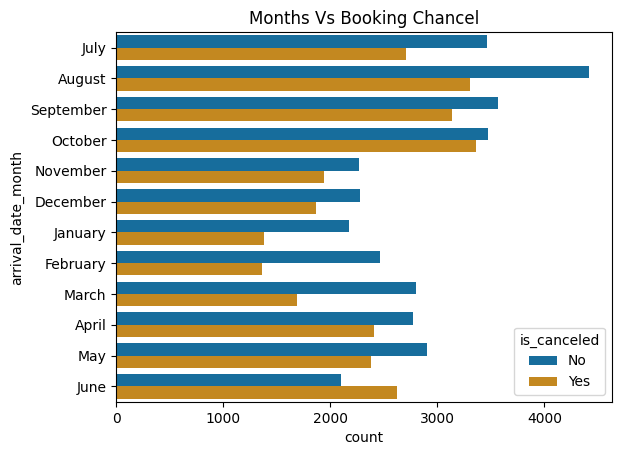

In [64]:
sns.countplot(y="arrival_date_month",hue="is_canceled",data=df,palette="colorblind")
plt.title("Months Vs Booking Chancel")
plt.show()

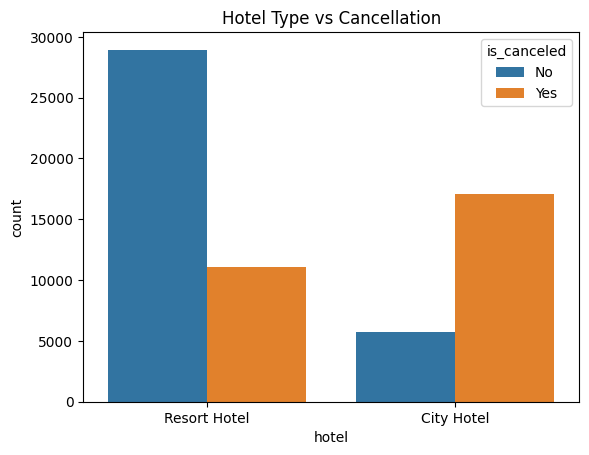

In [65]:
sns.countplot(x='hotel', hue='is_canceled', data=df)
plt.title("Hotel Type vs Cancellation")
plt.show()

Insight:  
City hotels → more cancellations

Text(0.5, 1.0, ' Previous cancellations VS Cancel Risk')

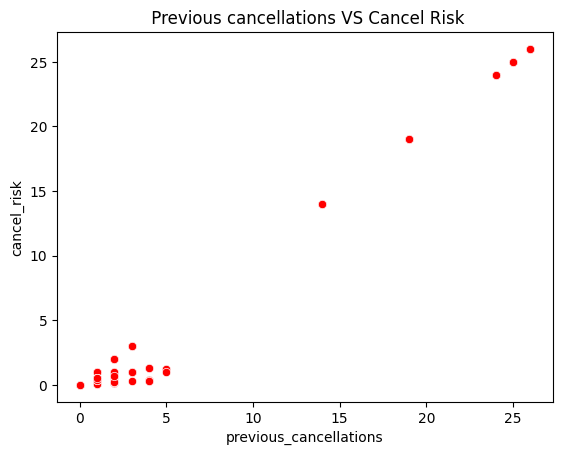

In [66]:
sns.scatterplot(data=df,x="previous_cancellations",y="cancel_risk",color="red")
plt.title(" Previous cancellations VS Cancel Risk")

<Axes: xlabel='arrival_date_day_of_month', ylabel='count'>

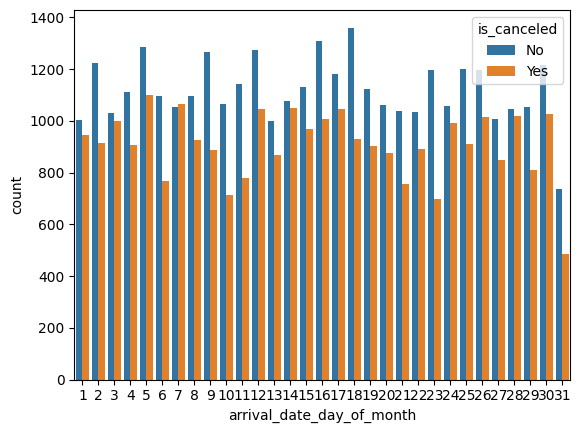

In [67]:
sns.countplot(x='arrival_date_day_of_month', hue='is_canceled', data=df)

In [68]:
df.sample(2)

,hotel,is_canceled,arrival_date_month,market_segment,distribution_channel,assigned_room_type,customer_type,reservation_status_date,arrival_date_year,arrival_date_day_of_month,is_repeated_guest,previous_cancellations,booking_changes,days_in_waiting_list,adr,total_of_special_requests,total_stay,family,cancel_risk
31332,Resort Hotel,No,December,Online TA,TA/TO,H,Transient,2016-12-24,2016,23,0,0,2,0,87.00,2,1,3.0,0.0
792,Resort Hotel,Yes,July,Offline TA/TO,TA/TO,D,Transient,2015-04-15,2015,29,0,0,0,0,90.95,0,7,2.0,0.0


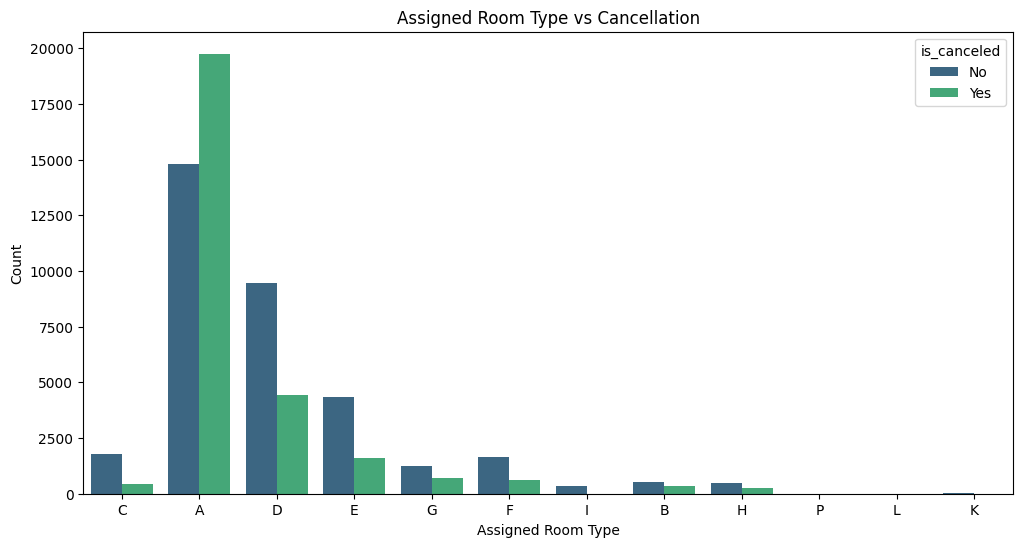

In [69]:
plt.figure(figsize=(12,6))

sns.countplot(
    x="assigned_room_type",
    hue="is_canceled",
    data=df,
    palette="viridis"
)

plt.title("Assigned Room Type vs Cancellation")
plt.xlabel("Assigned Room Type")
plt.ylabel("Count")

plt.show()

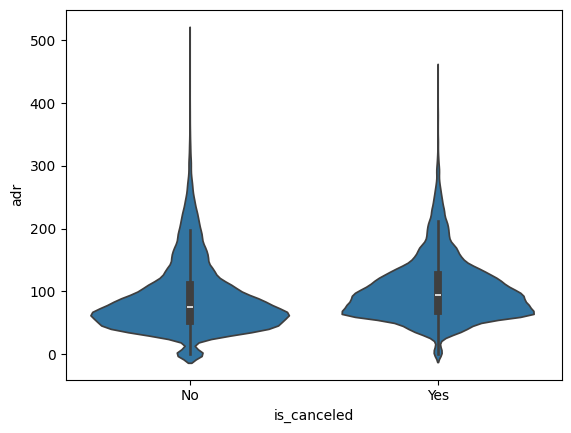

In [70]:
sns.violinplot(x='is_canceled', y='adr', data=df)
plt.show()

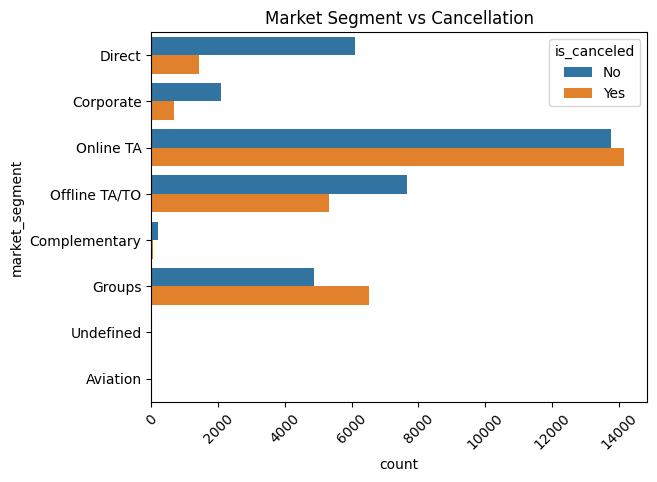

In [81]:
sns.countplot(y='market_segment', hue='is_canceled', data=df)
plt.xticks(rotation=45)
plt.title("Market Segment vs Cancellation")
plt.show()

Insight:  
Some segments (like Online) cancel more





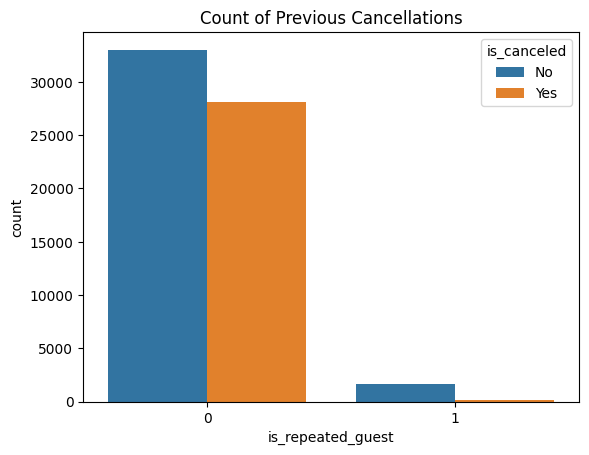

In [74]:
sns.countplot(x="is_repeated_guest", hue='is_canceled', data=df)
plt.title("Count of Previous Cancellations")
plt.show()

no repeated customer has lead for cancel there booking

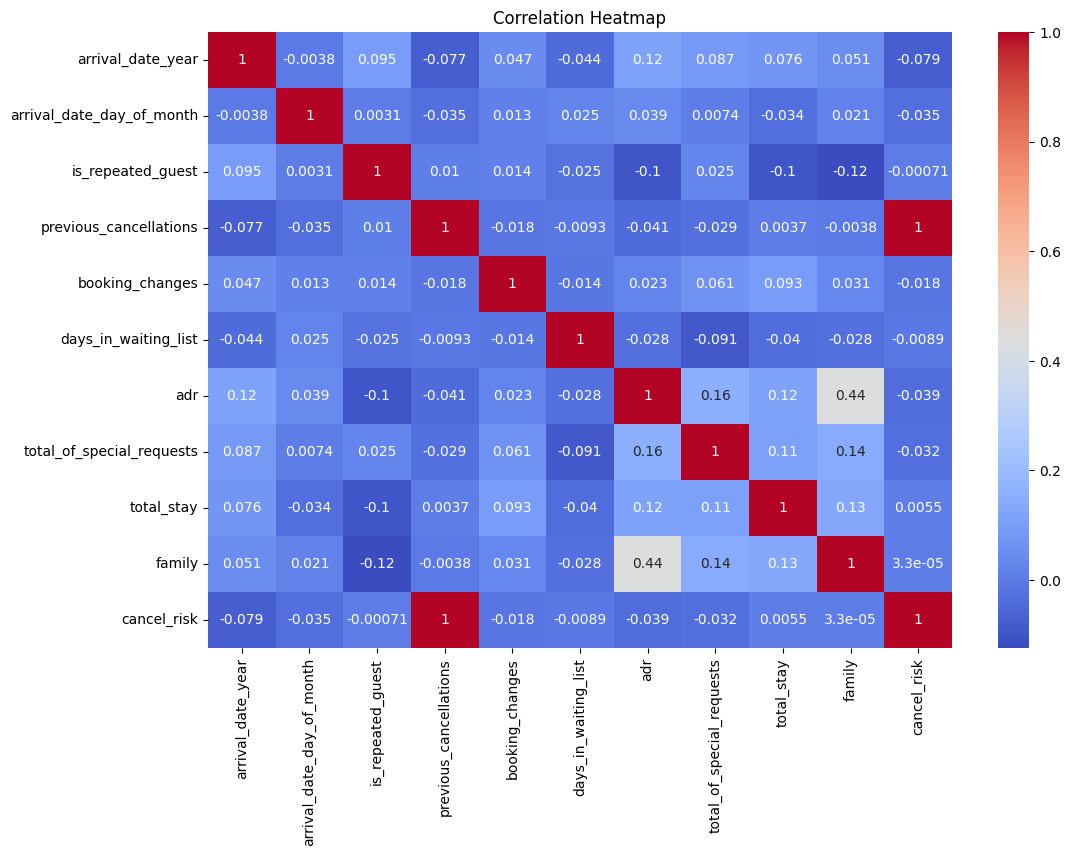

In [76]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm',annot=True)

plt.title("Correlation Heatmap")
plt.show()

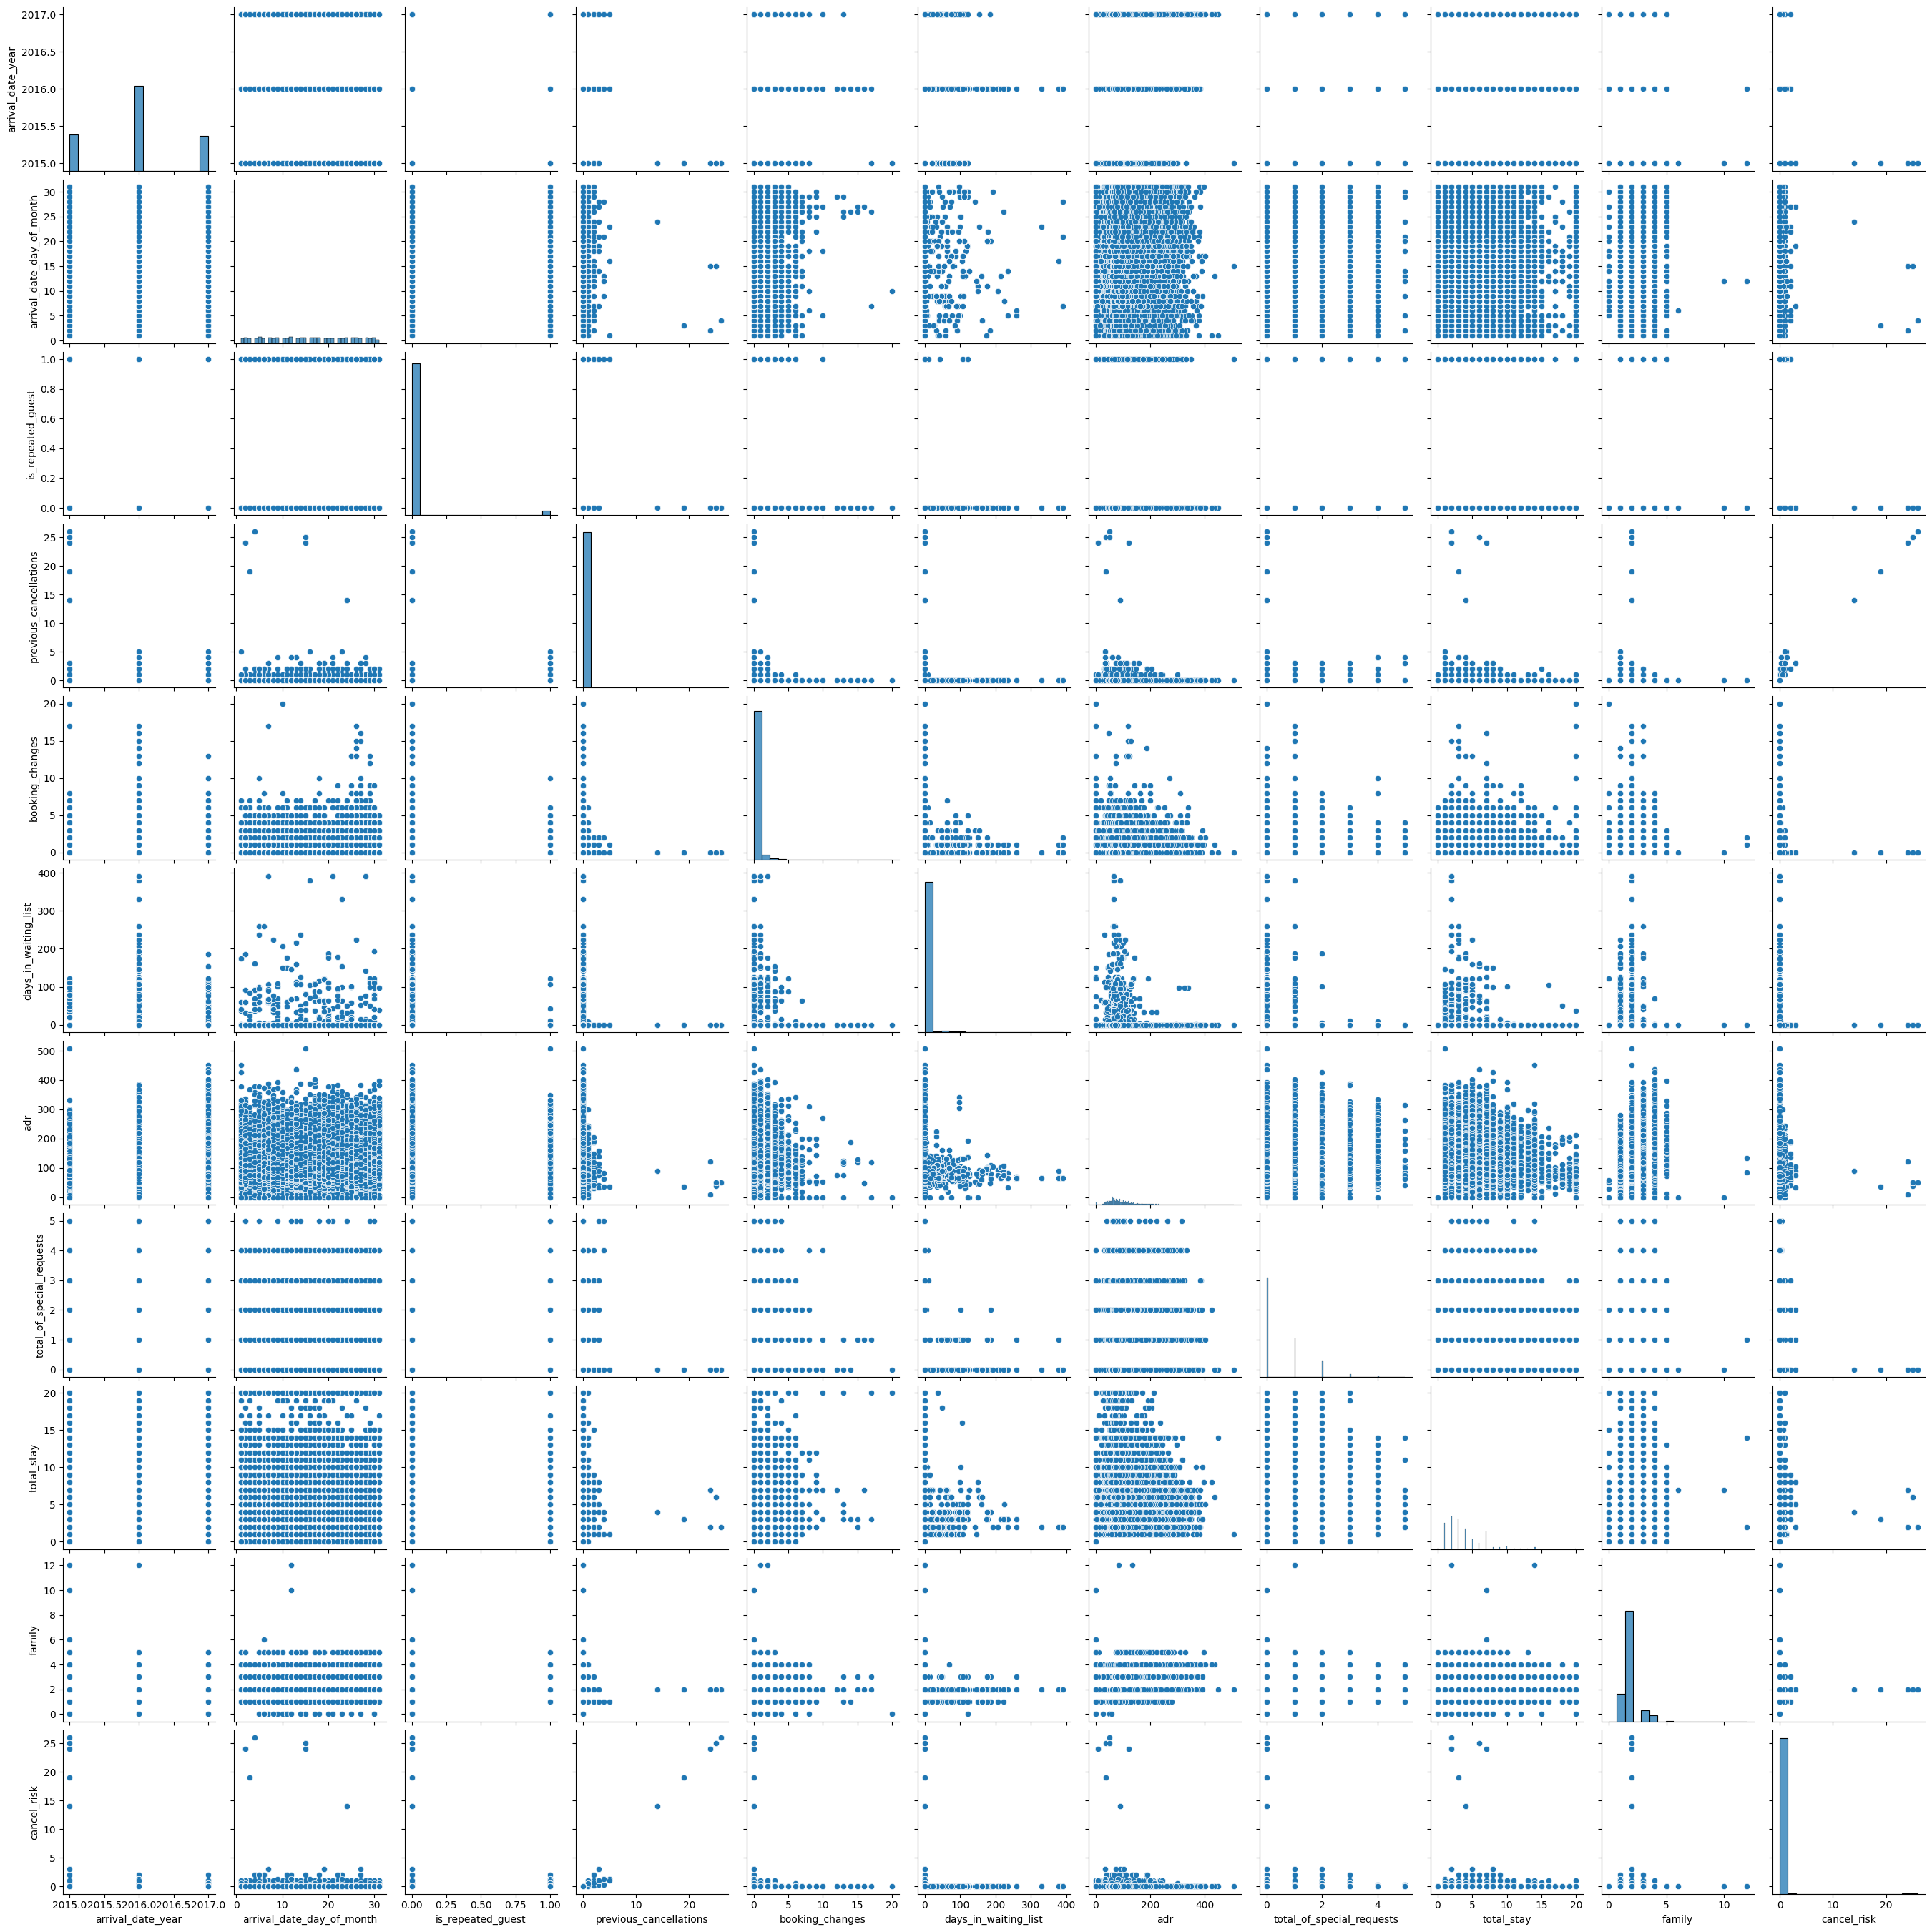

In [77]:
sns.pairplot(df)